# Sistema de Recomendación de Películas con Deep Learning

Este notebook documenta el proceso de creación de un modelo de filtrado colaborativo neuronal (NCF) para predecir los gustos de los usuarios utilizando el dataset MovieLens 1M.

## Fase 1: Análisis Exploratorio

### 1.1 Carga de Datos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Definimos las rutas a los archivos
ratings = pd.read_csv('../data/raw/ratings.dat', sep='::', names=['user_id', 'movie_id', 'rating', 'timestamp'], engine='python', encoding='latin-1')
movies = pd.read_csv('../data/raw/movies.dat', sep='::', names=['movie_id', 'title', 'genres'], engine='python', encoding='latin-1')
users = pd.read_csv('../data/raw/users.dat', sep='::', names=['user_id', 'gender', 'age', 'occupation', 'zip'], engine='python', encoding='latin-1')

print("¡Datos cargados con éxito!")
print(f"Tenemos {len(ratings)} calificaciones, {len(movies)} películas y {len(users)} usuarios.")

¡Datos cargados con éxito!
Tenemos 1000209 calificaciones, 3883 películas y 6040 usuarios.


### 1.2 Distribución de las Calificaciones

C:\Users\Jonathan\AppData\Local\Temp\ipykernel_19784\2034744729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=ratings, palette='viridis')


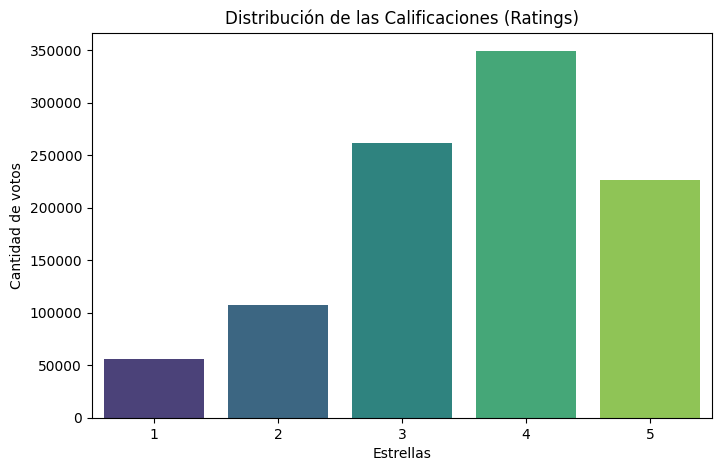

<Figure size 640x480 with 0 Axes>

In [36]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=ratings, palette='viridis')
plt.title('Distribución de las Calificaciones (Ratings)')
plt.xlabel('Estrellas')
plt.ylabel('Cantidad de votos')
plt.show()
plt.savefig('../reports/figures/distribucion_ratings.png')

### 1.3 Análisis de Dispersión (Sparsity)

In [3]:
n_users = ratings['user_id'].nunique()
n_items = ratings['movie_id'].nunique()
n_ratings = len(ratings)

sparsity = (1 - n_ratings / (n_users * n_items)) * 100
print(f"La dispersión de los datos es del: {sparsity:.2f}%")

La dispersión de los datos es del: 95.53%


### 1.4 Análisis de Popularidad (Long Tail)

In [4]:
# Combinamos las tablas de ratings y películas para ver los nombres
movie_data = pd.merge(ratings, movies, on='movie_id')
popular_movies = movie_data.groupby('title')['rating'].count().sort_values(ascending=False).head(10)

print("Top 10 películas más calificadas:")
print(popular_movies)

Top 10 películas más calificadas:
title
American Beauty (1999)                                   3428
Star Wars: Episode IV - A New Hope (1977)                2991
Star Wars: Episode V - The Empire Strikes Back (1980)    2990
Star Wars: Episode VI - Return of the Jedi (1983)        2883
Jurassic Park (1993)                                     2672
Saving Private Ryan (1998)                               2653
Terminator 2: Judgment Day (1991)                        2649
Matrix, The (1999)                                       2590
Back to the Future (1985)                                2583
Silence of the Lambs, The (1991)                         2578
Name: rating, dtype: int64


## Fase 2: Preparación de Datos para Deep Learning

### 2.1 Codificación de Identificadores

In [5]:
# Convertimos los IDs a categorías que empiecen desde 0
ratings['user'] = ratings['user_id'].astype('category').cat.codes
ratings['movie'] = ratings['movie_id'].astype('category').cat.codes

# Guardamos cuántos usuarios e ítems únicos tenemos ahora
n_users = ratings['user'].nunique()
n_items = ratings['movie'].nunique()

print(f"Total de usuarios únicos: {n_users}")
print(f"Total de ítems únicos: {n_items}")

Total de usuarios únicos: 6040
Total de ítems únicos: 3706


In [6]:
from sklearn.model_selection import train_test_split

# Dividimos: 80% para aprender, 20% para examen final
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

print(f"Registros para entrenar: {len(train)}")
print(f"Registros para probar: {len(test)}")

Registros para entrenar: 800167
Registros para probar: 200042


In [7]:
# Escalamos los ratings para que el máximo sea 1.0 y el mínimo cercano a 0
train_ratings = train['rating'].values.astype(float)
test_ratings = test['rating'].values.astype(float)

# Nota: Dividimos entre 5 porque es el máximo de estrellas
train_ratings_norm = train_ratings / 5.0
test_ratings_norm = test_ratings / 5.0

## Fase 3: Implementación del Modelo (Neural Collaborative Filtering)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Definimos las entradas
user_input = layers.Input(shape=(1,), name='user_input')
movie_input = layers.Input(shape=(1,), name='movie_input')

# 2. Creamos los "perfiles"
embedding_size = 50

user_embedding = layers.Embedding(n_users, embedding_size, name='user_embedding')(user_input)
movie_embedding = layers.Embedding(n_items, embedding_size, name='movie_embedding')(movie_input)

# 3. Aplanamos los perfiles para que se puedan procesar
user_vec = layers.Flatten()(user_embedding)
movie_vec = layers.Flatten()(movie_embedding)

# 4. Combinamos ambos perfiles
prod = layers.Dot(axes=1)([user_vec, movie_vec])

# 5. Capas "profundas"
dense = layers.Dense(64, activation='relu')(prod)
dense = layers.Dense(32, activation='relu')(dense)
output = layers.Dense(1, activation='sigmoid')(dense)

# 6. Armamos el modelo
model = models.Model(inputs=[user_input, movie_input], outputs=output)

# 7. Compilamos
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 50)     │    302,000 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 50)     │    185,300 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot (Dot)           │ (None, 1)         │          0 │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        128 │ dot[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 489,541 (1.87 MB)

 Trainable params: 489,541 (1.87 MB)

 Non-trainable params: 0 (0.00 B)

## Fase 4: Evaluación y Análisis de Resultados

### 4.1 Curva de Aprendizaje

In [ ]:
# Le decimos a la IA que estudie los datos 5 epocas
# Usamos lotes de 64
history = model.fit(
    [train['user'], train['movie']], 
    train_ratings_norm, 
    epochs=5, 
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - loss: 0.0438 - val_loss: 0.0321
Epoch 2/5
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0260 - val_loss: 0.0319
Epoch 3/5
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0202 - val_loss: 0.0336
Epoch 4/5
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0173 - val_loss: 0.0345
Epoch 5/5
11253/11253 ━━━━━━━━━━━━━━━━━━━━ 31s 3ms/step - loss: 0.0156 - val_loss: 0.0358


In [34]:
# Guarda el "cerebro" de tu IA en un archivo
model.save('../models/modelo_ncf_v1.h5')
print("¡Modelo guardado en la carpeta models!")

¡Modelo guardado en la carpeta models!


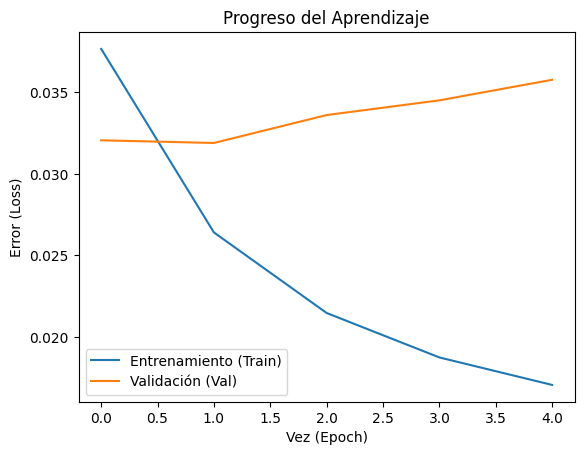

<Figure size 640x480 with 0 Axes>

In [37]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Entrenamiento (Train)')
plt.plot(history.history['val_loss'], label='Validación (Val)')
plt.title('Progreso del Aprendizaje')
plt.xlabel('Vez (Epoch)')
plt.ylabel('Error (Loss)')
plt.legend()
plt.show()
plt.savefig('../reports/figures/curva_aprendizaje.png')

### 4.2 Error Cuadrático Medio (RMSE)

In [ ]:
import numpy as np

# predecir los resultados del examen (test)
predictions = model.predict([test['user'], test['movie']])

# Como normalizamos antes (0 a 1), multiplicamos por 5 para volver a tener "estrellas"
predictions_stars = predictions.flatten() * 5
real_stars = test['rating'].values

# Calculamos el error
error = np.sqrt(np.mean((predictions_stars - real_stars)**2))
print(f"La IA se equivoca, en promedio, por: {error:.2f} estrellas")

6252/6252 ━━━━━━━━━━━━━━━━━━━━ 5s 777us/step
La IA se equivoca, en promedio, por: 0.95 estrellas


## Fase 5: Generación de Recomendaciones Personalizadas

In [32]:
# --- CELDA DE RECOMENDACIÓN FINAL ---

# 1. Elegimos un usuario al azar
user_id_test = ratings['user_id'].sample(1).iloc[0]
user_index = ratings[ratings['user_id'] == user_id_test]['user'].iloc[0]

print(f"--- Generando recomendaciones para el Usuario: {user_id_test} ---")

# 2. Identificamos qué películas NO ha visto ESTE usuario específico
movies_watched = ratings[ratings['user_id'] == user_id_test]['movie_id'].values
existing_movie_ids = ratings['movie_id'].unique()
# Esta es la lista de películas nuevas para él
movies_to_predict = [m for m in existing_movie_ids if m not in movies_watched]

# 3. Convertimos a los códigos que la IA entiende (índices 0 a N)
movie_indices = ratings[ratings['movie_id'].isin(movies_to_predict)]['movie'].unique()

# 4. Preparamos los datos en forma de columna (Reshape)
user_array = np.array([user_index] * len(movie_indices), dtype='int32').reshape(-1, 1)
movie_array = np.array(movie_indices, dtype='int32').reshape(-1, 1)

# 5. La IA predice los ratings
pred_ratings = model.predict([user_array, movie_array], verbose=0)

# 6. Tomamos las 5 mejores
top_indices_in_pred = pred_ratings.flatten().argsort()[-5:][::-1]
top_movie_indices = movie_indices[top_indices_in_pred]

print(f"\nBasado en tus gustos, nuestra IA te recomienda:")
for i, m_idx in enumerate(top_movie_indices, 1):
    movie_id_real = ratings[ratings['movie'] == m_idx]['movie_id'].iloc[0]
    title = movies[movies['movie_id'] == movie_id_real]['title'].values[0]
    genre = movies[movies['movie_id'] == movie_id_real]['genres'].values[0]
    print(f"{i}. {title} | Género: {genre}")

--- Generando recomendaciones para el Usuario: 817 ---

Basado en tus gustos, nuestra IA te recomienda:
1. Wizard of Oz, The (1939) | Género: Adventure|Children's|Drama|Musical
2. Exorcist, The (1973) | Género: Horror
3. Psycho (1960) | Género: Horror|Thriller
4. Mr. Smith Goes to Washington (1939) | Género: Drama
5. Perfect Blue (1997) | Género: Animation|Mystery
